In [207]:
import pandas as pd
import numpy as np
# from scipy.optimize import curve_fit
from scipy.optimize import minimize
from numpy import linalg
import matplotlib.pyplot as plt

In [208]:
def sqrt_func(x, a, b):
    return a * np.sqrt(x - b)

def coldhead_power(coldhead_temp):
    # curve fit results from data points in ARS manual:
    # coldhead_curve_x = np.array([35, 50, 75, 125, 155, 210]) # Kelvin
    # coldhead_curve_y = np.array([30, 40, 60, 85, 95, 110]) # Watts
    power = sqrt_func(coldhead_temp, 8.17430058, 22.45378994)
    return power

def coldhead_power_with_efficiency(coldhead_temp, eff):
    # corrected coldhead power in cases where coldhead is < 100% efficient
    # ideally, 0 < eff <= 1
    power = eff * coldhead_power(coldhead_temp)
    return power

In [209]:
def temp_matrix_1_eq_point(T_tb, T_tc, T_bc):
    '''
    Make a temperature matrix (i.e. voltage in the circuit analogy) for one equilibrium point.
    Operates on conductivity matrix to produce heater powers for that eq. point.
    INPUTS:
    T_tb, T_tc, T_bc: all scalars
    '''
    A = np.array([[T_tb, T_tc, 0],
                  [-T_tb, 0, T_bc],
                  [0, T_tc, T_bc]
                  ])
    return A

In [210]:
def get_stacked_temp_matrix(T_tb_1d, T_tc_1d, T_bc_1d):
    '''
    Make a stacked temperature matrix from all equilibrium points.
    INPUTS:
    T_tb_1d, T_tc_1d, T_bc_1d: all 1D Numpy arrays
    '''
    temp_matrix_list = []

    for i in range(T_tb_1d.shape[0]):
        A = temp_matrix_1_eq_point(T_tb_1d[i], T_tc_1d[i], T_bc_1d[i])
        temp_matrix_list.append(A)

    temp_matrices = tuple(temp_matrix_list)
    temp_matrix = np.vstack(temp_matrices)

    return temp_matrix

In [211]:
def power_matrix(T_coldhead_1d, heater1_power_1d, heater2_power_1d, i0, coldhead_efficiency):
    '''
    Get power matrix (i.e. current in the circuit analogy) for 1 equilibrium point.
    INPUTS:
    - T_coldhead_1d, 1D numpy array
    - heater_1_power_1d, 1D numpy array
    - heater_2_power_1d, 1D numpy array
    - i0, scalar
    - coldhead_efficiency, scalar
    '''
    power_CH = coldhead_power_with_efficiency(T_coldhead_1d, coldhead_efficiency)
    num_points = T_coldhead_1d.shape[0] # number of equilibrium points in the dataset

    powers_list = []

    for i in range(num_points):
        A = np.array([-1 * (i0 + heater2_power_1d[i]),
                      -1 * heater1_power_1d[i], 
                      -1 * power_CH[i]])
        powers_list.append(A)

    powers_matrices = tuple(powers_list)
    powers = np.hstack(powers_matrices)

    return powers

In [212]:
def get_conductivities(temp_matrix_stacked, powers_matrix_stacked):
    '''
    Computes approximate least squares conductivities fit for solution to
    temp_matrix_stacked * conductivity_matrix = powers_matrix_stacked.
    Uses the Moore-Penrose pseudoinverse for the underdetermined problem here.
    '''
    pinv_temp = linalg.pinv(temp_matrix_stacked)
    conductivities = np.matmul(pinv_temp, powers_matrix_stacked)

    C_top_bottom = conductivities[0]
    C_top_coldhead = conductivities[1]
    C_bottom_coldhead = conductivities[2]
    
    return C_top_bottom, C_top_coldhead, C_bottom_coldhead


In [213]:
def predict_top_bot_temp_1_eq_point(T_coldhead, # scalar
                                    heater_1_power, # scalar
                                    heater_2_power, # scalar
                                    i0,
                                    coldhead_efficiency,
                                    C_top_bottom,
                                    C_top_coldhead,
                                    C_bottom_coldhead,
                                    ):
#     C_Cross = C_top_bottom*C_top_coldhead + C_top_bottom*C_bottom_coldhead + C_top_coldhead*C_bottom_coldhead
    
    #P_CH = coldhead_power_with_efficiency(T_coldhead, coldhead_efficiency)
    pass

In [214]:
def calc_bot_top_temp(T_CH, i1, i2, i0, CH_eff, C_tb, C_tc, C_bc):
    C_cross = C_tb*C_tc + C_tb*C_bc + C_tc*C_bc
    i_tot = i1 + i2 + i0
    T_0 = T_CH - (C_tb * i_tot / C_cross)
    
    T_b = T_0 - (C_tc * i1 / C_cross)
    T_t = T_0 - (C_bc * (i0+i2) / C_cross)
    return T_b, T_t

In [215]:
def loss_function(params):
    i0, CH_eff = params
    
    powers = power_matrix(data["CH_Temp"], data["Heater1"], data["Heater2"], i0, CH_eff)
    C_tb, C_tc, C_bc = get_conductivities(A_stacked, powers)
    
    T_b_calc, T_t_calc = calc_bot_top_temp(
        data["CH_Temp"], data["Heater1"], data["Heater2"], i0, CH_eff, C_tb, C_tc, C_bc
    )
    
    err_bot = np.mean((T_b_calc - data["Bot_Temp"]) ** 2)
    err_top = np.mean((T_t_calc - data["Top_Temp"]) ** 2)
#     return np.sqrt(err_bot + err_top)
    return (err_bot + err_top)

In [216]:
path = f"D:\\CrystaLiZe\\equilibrium_data_7_10_2026.csv"
df = pd.read_csv(path)

mass = 6
phase = "Partial"
df_mass = df["Xe mass [kg]"]
df_phase = df["Phase [Liquid, Solid, Partial, or TBD]"]

mask = (df_mass == mass) & (df_phase == phase) # & (df['Max Heater 1 Output (W)'] != 0)
df = df[mask]

Temp_mask = (df['Min Top Flange Temp (K)'] > 172) & (df['Max Top Flange Temp (K)'] < 174)
df = df[Temp_mask]

data_Min = {
    "Bot_Temp": df['Min Bottom Flange Temp (K)'].to_numpy(),
    "Top_Temp": df['Min Top Flange Temp (K)'].to_numpy(), 
    "CH_Temp": df['Min Coldhead Temp (K)'].to_numpy(), 
    "Heater1": df['Min Heater 1 Output (W)'].to_numpy(), 
    "Heater2": df['Min Heater 2 Output (W)'].to_numpy(), 
    }
data_Max = {
    "Bot_Temp": df['Max Bottom Flange Temp (K)'].to_numpy(),
    "Top_Temp": df['Max Top Flange Temp (K)'].to_numpy(), 
    "CH_Temp": df['Max Coldhead Temp (K)'].to_numpy(), 
    "Heater1": df['Max Heater 1 Output (W)'].to_numpy(), 
    "Heater2": df['Max Heater 2 Output (W)'].to_numpy(), 
    }
data_Median = {
    "Bot_Temp": df['Median Bottom Flange Temp (K)'].to_numpy(),
    "Top_Temp": df['Median Top Flange Temp (K)'].to_numpy(), 
    "CH_Temp": df['Median Coldhead Temp (K)'].to_numpy(), 
    "Heater1": df['Median Heater 1 Output (W)'].to_numpy(), 
    "Heater2": df['Median Heater 2 Output (W)'].to_numpy(), 
    }

In [217]:
data = data_Median
CH_power = coldhead_power(data["CH_Temp"])

T_TB = (data["Top_Temp"] - data["Bot_Temp"])
T_TC = (data["Top_Temp"] - data["CH_Temp"])
T_BC = (data["Bot_Temp"] - data["CH_Temp"])
A_stacked = get_stacked_temp_matrix(T_TB, T_TC, T_BC)

# powers = power_matrix(data_Min["CH_Temp"], data_Min["Heater2"], i0, CH_efficiency)
# C_tb, C_tc, C_bc = get_conductivities(A_stacked, powers)

# methods:
**BFGS**: 无约束优化，拟牛顿法。
**Nelder-Mead**: 无约束优化，简单的单纯形法，适用于无导数的情况。
**L-BFGS-B**: 有界优化，类似BFGS，但支持边界条件。
**trust-constr**: 适用于有约束优化的信任区域方法。

In [218]:
'''
initial_guess = [0.1, 0.9]

# bound restrictions: i0 >= 0, 0 < CH_efficiency <= 1.0
bounds = [(0, 5), (1e-3, 1.0)]

result = minimize(loss_function, initial_guess, bounds=bounds, method='L-BFGS-B')
best_i0, best_eff = result.x

print(f"i0           : {best_i0:.4f} W")
print(f"CH_efficiency: {best_eff * 100:.2f}%")
print(f"loss_function: {loss_function([best_i0, best_eff])}")
print(f"log10(loss_function) : {np.log10(loss_function([best_i0, best_eff]))}")
print(f"sqrt(loss_function/2): {np.sqrt(0.5*loss_function([best_i0, best_eff]))} K")
'''

'\ninitial_guess = [0.1, 0.9]\n\n# bound restrictions: i0 >= 0, 0 < CH_efficiency <= 1.0\nbounds = [(0, 5), (1e-3, 1.0)]\n\nresult = minimize(loss_function, initial_guess, bounds=bounds, method=\'L-BFGS-B\')\nbest_i0, best_eff = result.x\n\nprint(f"i0           : {best_i0:.4f} W")\nprint(f"CH_efficiency: {best_eff * 100:.2f}%")\nprint(f"loss_function: {loss_function([best_i0, best_eff])}")\nprint(f"log10(loss_function) : {np.log10(loss_function([best_i0, best_eff]))}")\nprint(f"sqrt(loss_function/2): {np.sqrt(0.5*loss_function([best_i0, best_eff]))} K")\n'

In [236]:
i0_start, i0_end = 0.0, 5.0
eff_start, eff_end = 1.0, 1.00
# bounds = [(i0_start, i0_end), (eff_start, eff_end)]
bounds = [(0, 60), (1, 1)]

i0_guesses = np.linspace(i0_start, i0_end, 21)
eff_guesses = np.linspace(eff_start, eff_end, 2)
best_result = None
best_i0_guess, best_eff_guess = None, None
guess = [0,0]

for i0_guess in i0_guesses:
    for eff_guess in eff_guesses:
        guess = [i0_guess, eff_guess]
        result = minimize(loss_function, guess, bounds=bounds, method='L-BFGS-B')
#         print(f"loss_function = {result.fun}")
        if (best_result == None) or (result.fun < best_result.fun):
            best_result = result
            best_i0_guess, best_eff_guess = i0_guess, eff_guess
        

best_i0, best_eff = best_result.x
error = best_result.fun
print(f"i0_guess     : {best_i0_guess:.4f} W")
print(f"CH_eff_guess : {best_eff_guess * 100:.2f}%")
print(f"i0           : {best_i0:.4f} W")
print(f"CH_eff       : {best_eff * 100:.2f}%")
print(f"loss_function: {error:.2f}")

i0_guess     : 1.7500 W
CH_eff_guess : 100.00%
i0           : 48.6603 W
CH_eff       : 100.00%
loss_function: 32.82


In [220]:
powers = power_matrix(data["CH_Temp"], data["Heater1"], data["Heater2"], best_i0, best_eff)
C_tb, C_tc, C_bc = get_conductivities(A_stacked, powers)

T_b_calc, T_t_calc = calc_bot_top_temp(
        data["CH_Temp"], data["Heater1"], data["Heater2"], best_i0, best_eff, C_tb, C_tc, C_bc
    )
print(T_b_calc)
print(T_t_calc)

[148.23240408 149.07001142 150.47570797 150.82990292 150.6998761
 150.33336086 150.76264243 151.06518774 161.63285793 161.30967531]
[173.08006615 173.97509667 175.48059793 175.86077392 175.71980771
 175.33688341 175.00894812 174.52419327 166.7708353  166.43944815]


In [221]:
title_string = f'Equilibrium State of {mass} kg {phase} Xenon'
print(title_string)
conductivity = f'C_tb = {C_tb}, C_tc = {C_tc}, C_bc = {C_bc} [W/K]'
print(conductivity)

Equilibrium State of 6 kg Partial Xenon
C_tb = 0.24236003650697135, C_tc = -0.7878917161231893, C_bc = 0.01717401015025377 [W/K]


In [222]:
boot_idx = np.random.choice(7, size=5, replace=False)
print(boot_idx)
data_bot = {k: v[boot_idx] for k, v in data.items()}
print(data_bot)

[2 6 5 0 4]
{'Bot_Temp': array([152.602, 151.895, 152.51 , 152.62 , 152.587]), 'Top_Temp': array([173.686 , 173.398 , 173.687 , 173.735 , 173.6815]), 'CH_Temp': array([88.62725, 88.20675, 88.5042 , 88.60275, 88.63915]), 'Heater1': array([4.998, 4.802, 4.998, 4.998, 4.998]), 'Heater2': array([14.36915, 14.5127 , 14.3532 , 12.5352 , 14.5446 ])}


In [223]:
def run_bootstrap_uncertainty(data_dict, n_bootstraps):
    n_samples = len(data_dict["CH_Temp"])
    
    Tb_pred_list = []
    Tt_pred_list = []   
    print(f"Perform {n_bootstraps} times Bootstrap error estimation")    
    
    for b in range(n_bootstraps):
        boot_idx = np.random.choice(n_samples, size=n_samples, replace=True)
        data_boot = {k: v[boot_idx] for k, v in data_dict.items()}
        
        T_TB_b = data_boot["Top_Temp"] - data_boot["Bot_Temp"]
        T_TC_b = data_boot["Top_Temp"] - data_boot["CH_Temp"]
        T_BC_b = data_boot["Bot_Temp"] - data_boot["CH_Temp"]
        A_boot = get_stacked_temp_matrix(T_TB_b, T_TC_b, T_BC_b)
           
        def loss_boot(params):
            i0, CH_eff = params
            powers = power_matrix(data_boot["CH_Temp"], data_boot["Heater1"], data_boot["Heater2"], i0, CH_eff)
            C_tb, C_tc, C_bc = get_conductivities(A_boot, powers)
            Tb_c, Tt_c = calc_bot_top_temp(
                data_boot["CH_Temp"], data_boot["Heater1"], data_boot["Heater2"], i0, CH_eff, C_tb, C_tc, C_bc
            )
            return np.mean((Tb_c - data_boot["Bot_Temp"])**2) + np.mean((Tt_c - data_boot["Top_Temp"])**2)

        initial_guess = [0.1, 0.9]
        bounds = [(0, 5), (1e-3, 1.0)]
        res_b = minimize(loss_boot, initial_guess, bounds=bounds, method='L-BFGS-B')
        i0_b,CH_eff_b = res_b.x
        
        powers_b = power_matrix(data_boot["CH_Temp"], data_dict["Heater1"], data_boot["Heater2"], i0_b, CH_eff_b)
        C_tb_b, C_tc_b, C_bc_b = get_conductivities(A_boot, powers_b)
        
        Tb_pred, Tt_pred = calc_bot_top_temp(
            data_dict["CH_Temp"], data_dict["Heater1"], data_dict["Heater2"], 
            i0_b, CH_eff_b, C_tb_b, C_tc_b, C_bc_b)
        
        Tb_pred_list.append(Tb_pred)
        Tt_pred_list.append(Tt_pred)
        
    Tb_pred_array = np.array(Tb_pred_list)
    Tt_pred_array = np.array(Tt_pred_list)
    
    Tb_mean = np.mean(Tb_pred_array, axis=0)
    Tb_err = np.std(Tb_pred_array, axis=0)  
    Tt_mean = np.mean(Tt_pred_array, axis=0)
    Tt_err = np.std(Tt_pred_array, axis=0)  
    
    return Tb_mean, Tb_err, Tt_mean, Tt_err

Tb_mean, Tb_err, Tt_mean, Tt_err = run_bootstrap_uncertainty(data, n_bootstraps=50)
print(Tb_mean, Tb_err, Tt_mean, Tt_err)

Perform 50 times Bootstrap error estimation
[150.42921521 152.36361097 155.67558736 156.52602258 156.18705248
 155.50712234 155.18956355 154.1706745  137.13269258 136.65280251] [ 8.3274359   7.84987003  7.13819899  6.98227903  7.04629573  7.14677146
  6.48210832  6.06712828 19.45318702 19.34462241] [170.35277113 172.96484914 177.45467532 178.61172686 178.14365516
 177.27007261 177.03007185 175.73371141 154.30563194 153.72891566] [8.13785588 8.34563948 8.71733071 8.81611679 8.77442558 8.71215366
 8.71139533 8.59939724 8.0865975  8.04586622]


In [224]:
from itertools import combinations

def run_bootstrap_uncertainty(data_dict):
    n_samples = len(data_dict["CH_Temp"])
    
    Tb_pred_list = []
    Tt_pred_list = []   
    
    subsets_1 = list(combinations(range(n_samples), n_samples-1))
    subsets_2 = list(combinations(range(n_samples), n_samples-2))
    subsets_3 = list(combinations(range(n_samples), n_samples-3))
    
    for idx_tuple in (subsets_3):
        boot_idx = np.array(idx_tuple)
        data_boot = {k: v[boot_idx] for k, v in data_dict.items()}
        
        T_TB_b = data_boot["Top_Temp"] - data_boot["Bot_Temp"]
        T_TC_b = data_boot["Top_Temp"] - data_boot["CH_Temp"]
        T_BC_b = data_boot["Bot_Temp"] - data_boot["CH_Temp"]
        A_boot = get_stacked_temp_matrix(T_TB_b, T_TC_b, T_BC_b)
           
        def loss_boot(params):
            i0, CH_eff = params
            powers = power_matrix(data_boot["CH_Temp"], data_boot["Heater1"], data_boot["Heater2"], i0, CH_eff)
            C_tb, C_tc, C_bc = get_conductivities(A_boot, powers)
            Tb_c, Tt_c = calc_bot_top_temp(
                data_boot["CH_Temp"], data_boot["Heater1"], data_boot["Heater2"], i0, CH_eff, C_tb, C_tc, C_bc
            )
            return np.mean((Tb_c - data_boot["Bot_Temp"])**2) + np.mean((Tt_c - data_boot["Top_Temp"])**2)

        initial_guess = [best_i0_guess, best_eff_guess]
        bounds = [(0, 100), (0.001, 1.0)]
        res_b = minimize(loss_boot, initial_guess, bounds=bounds, method='L-BFGS-B')
        i0_b,CH_eff_b = res_b.x
        
        powers_b = power_matrix(data_boot["CH_Temp"], data_boot["Heater1"], data_boot["Heater2"], i0_b, CH_eff_b)
        C_tb_b, C_tc_b, C_bc_b = get_conductivities(A_boot, powers_b)
        
        Tb_pred, Tt_pred = calc_bot_top_temp(
            data_dict["CH_Temp"], data_dict["Heater1"], data_dict["Heater2"], 
            i0_b, CH_eff_b, C_tb_b, C_tc_b, C_bc_b)
        
        Tb_pred_list.append(Tb_pred)
        Tt_pred_list.append(Tt_pred)
        
    Tb_pred_array = np.array(Tb_pred_list)
    Tt_pred_array = np.array(Tt_pred_list)
    
    Tb_mean = np.mean(Tb_pred_array, axis=0)
    Tb_err = np.std(Tb_pred_array, axis=0)  
    Tt_mean = np.mean(Tt_pred_array, axis=0)
    Tt_err = np.std(Tt_pred_array, axis=0)  
    
    return Tb_mean, Tb_err, Tt_mean, Tt_err

Tb_mean, Tb_err, Tt_mean, Tt_err = run_bootstrap_uncertainty(data)
print(Tb_mean, Tb_err, Tt_mean, Tt_err)

[145.45495167 146.54569488 148.39135579 148.86008169 148.68183131
 148.24298074 148.28446104 148.06659029 147.20028533 146.84093504] [46.84014371 47.07151917 47.55438482 47.69658782 47.6358923  47.5470873
 47.46329368 47.21970749 44.93855278 44.8504236 ] [171.60577013 172.76105248 174.71888602 175.21681256 175.02626717
 174.5689741  174.22893898 173.59574156 163.17215626 162.80358472] [15.10117301 15.21032484 15.46394739 15.54289149 15.50901486 15.45993768
 15.37299038 15.20964837 15.60879995 15.63415071]


In [225]:
def calc_data_errors(data_min, data_max, data_median):
    errors = {}
    for key in data_median.keys():
        err_down = data_median[key] - data_min[key]
        err_up = data_max[key] - data_median[key]
        errors[key] = np.array([err_down, err_up])
    return errors

def calc_model_residuals(t_b_measured, t_t_measured, t_b_calc, t_t_calc):
    res_bot = t_b_calc - t_b_measured
    res_top = t_t_calc - t_t_measured
    
    rmse_bot = np.sqrt(np.mean(res_bot ** 2))
    rmse_top = np.sqrt(np.mean(res_top ** 2))
    
    return {
        "res_bot": res_bot,
        "res_top": res_top,
        "rmse_bot": rmse_bot,
        "rmse_top": rmse_top
    }

In [226]:
data_err = calc_data_errors(data_Min, data_Max, data_Median)

powers = power_matrix(data_Median["CH_Temp"], data_Median["Heater1"], data_Median["Heater2"], best_i0, best_eff)
C_tb, C_tc, C_bc = get_conductivities(A_stacked, powers)

T_b_calc, T_t_calc = calc_bot_top_temp(
    data_Median["CH_Temp"], data_Median["Heater1"], data_Median["Heater2"], 
    best_i0, best_eff, C_tb, C_tc, C_bc
)

res_metrics = calc_model_residuals(data_Median["Bot_Temp"], data_Median["Top_Temp"], T_b_calc, T_t_calc)
print(f"Bottom Temp RMSE: {res_metrics['rmse_bot']:.4f} K")
print(f"Top Temp RMSE   : {res_metrics['rmse_top']:.4f} K")

Bottom Temp RMSE: 4.6922 K
Top Temp RMSE   : 3.2332 K


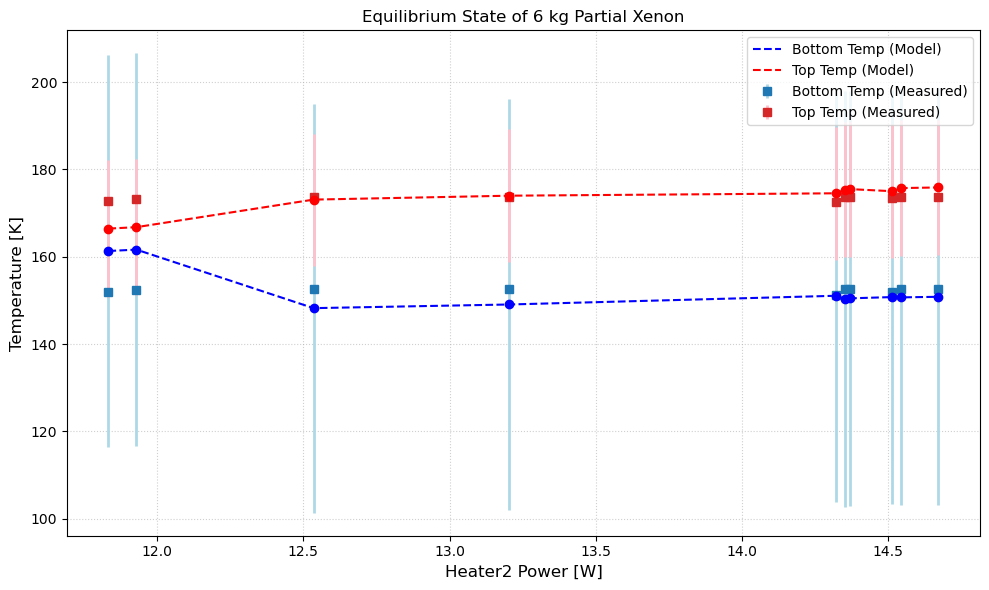

In [227]:
plt.figure(figsize=(10, 6))
Heater = "Heater2"
sort = np.argsort(data[Heater])
plt.errorbar(data[Heater][sort], data_Median["Bot_Temp"][sort], yerr=data_err["Bot_Temp"][:,sort], 
             fmt='s', color='tab:blue', ecolor='lightblue', elinewidth=2, label='Bottom Temp (Measured)')
plt.plot(data[Heater][sort], T_b_calc[sort], 'b--', linewidth=1.5, label='Bottom Temp (Model)')
plt.errorbar(data[Heater][sort], T_b_calc[sort], yerr=Tb_err[sort], 
             fmt='o', color='blue', ecolor='lightblue', elinewidth=2)

plt.errorbar(data[Heater][sort], data_Median["Top_Temp"][sort], yerr=data_err["Top_Temp"][:,sort], 
             fmt='s', color='tab:red', ecolor='pink', elinewidth=2, label='Top Temp (Measured)')
plt.plot(data[Heater][sort], T_t_calc[sort], 'r--', linewidth=1.5, label='Top Temp (Model)')
plt.errorbar(data[Heater][sort], T_t_calc[sort], yerr=Tt_err[sort], 
             fmt='o', color='red', ecolor='pink', elinewidth=2)

plt.xlabel(f"{Heater} Power [W]", fontsize=12)
plt.ylabel("Temperature [K]", fontsize=12)
plt.title(title_string)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

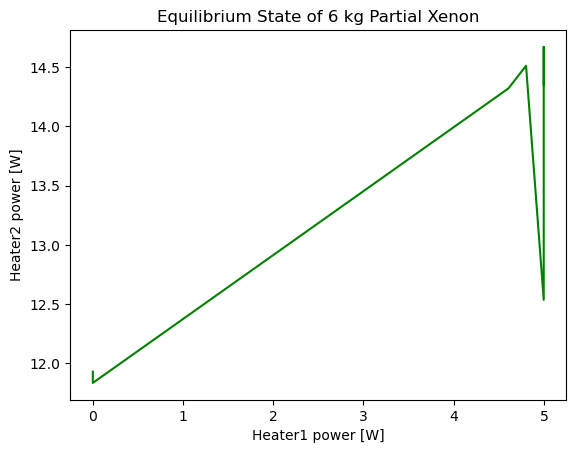

In [228]:
plt.figure()
plt.title(title_string)
Heater = "Heater1"
sort = np.argsort(data[Heater])
plt.plot(data["Heater1"][sort], data["Heater2"][sort], 'g')
plt.xlabel("Heater1 power [W]")
plt.ylabel("Heater2 power [W]")
plt.show()

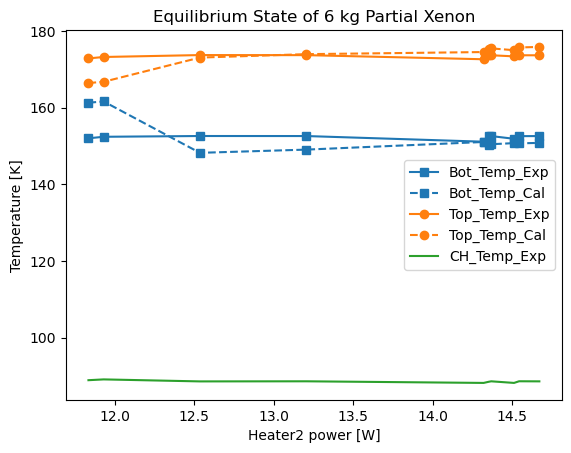

In [229]:
plt.figure()
plt.title(title_string)

sort_indices = np.argsort(data["Heater2"])
plt.plot(data["Heater2"][sort_indices], data["Bot_Temp"][sort_indices], 's-', color='tab:blue', label="Bot_Temp_Exp")
plt.plot(data["Heater2"][sort_indices], T_b_calc[sort_indices], 's--', color='tab:blue',  label="Bot_Temp_Cal")
plt.plot(data["Heater2"][sort_indices], data["Top_Temp"][sort_indices], 'o-', color='tab:orange', label="Top_Temp_Exp")
plt.plot(data["Heater2"][sort_indices], T_t_calc[sort_indices], 'o--', color='tab:orange', label="Top_Temp_Cal")
plt.plot(data["Heater2"][sort_indices], data["CH_Temp"][sort_indices], color='tab:green', label="CH_Temp_Exp")

plt.xlabel("Heater2 power [W]")
plt.ylabel("Temperature [K]")
plt.legend()
plt.show()

In [230]:
print(data["Top_Temp"])
print(np.mean(data["Top_Temp"]))
print(np.median(data["Top_Temp"]))

[173.735  173.716  173.686  173.679  173.6815 173.687  173.398  172.642
 173.234  172.864 ]
173.43225
173.68025


In [231]:
x = np.linspace(0, 50, 501) # i0
y = np.linspace(0.4, 1, 61) # CH_eff
Z = np.zeros((len(x), len(y)), float)
# Z = loss_function([X, Y])
for i in range(len(x)):
    for j in range(len(y)):
        Z[i,j] = np.log10(loss_function([x[i], y[j]]))

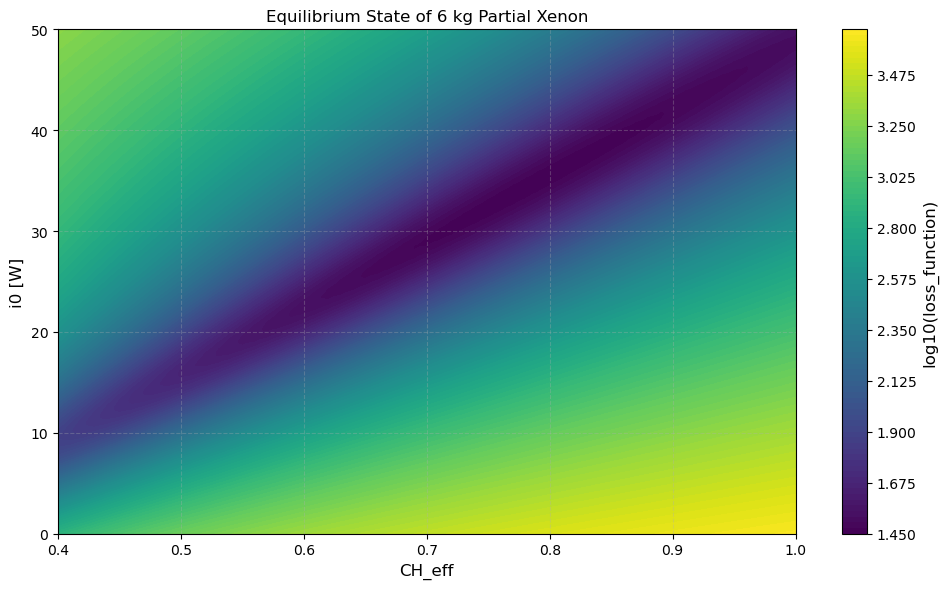

In [232]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=100)

# cmap：'viridis', 'plasma', 'coolwarm', 'jet', 'rainbow', so on
cp = ax.contourf(y, x, Z, levels=100, cmap='viridis')

colorbar = fig.colorbar(cp)
colorbar.set_label('log10(loss_function)', fontsize=12)

ax.set_title(title_string)
ax.set_ylabel('i0 [W]', fontsize=12)
ax.set_xlabel('CH_eff', fontsize=12)

ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [233]:
H1 = np.linspace(0, 20, 81) # Heater1
H2 = np.linspace(0, 30, 121) # Heater2
Tb_calc = np.zeros((len(H1), len(H2)), float)
Tt_calc = np.zeros((len(H1), len(H2)), float)
for i in range(len(H1)):
    for j in range(len(H2)):
        Tb_calc[i,j], Tt_calc[i,j] = calc_bot_top_temp(
        90, H1[i], H2[j], best_i0, best_eff, C_tb, C_tc, C_bc
    )

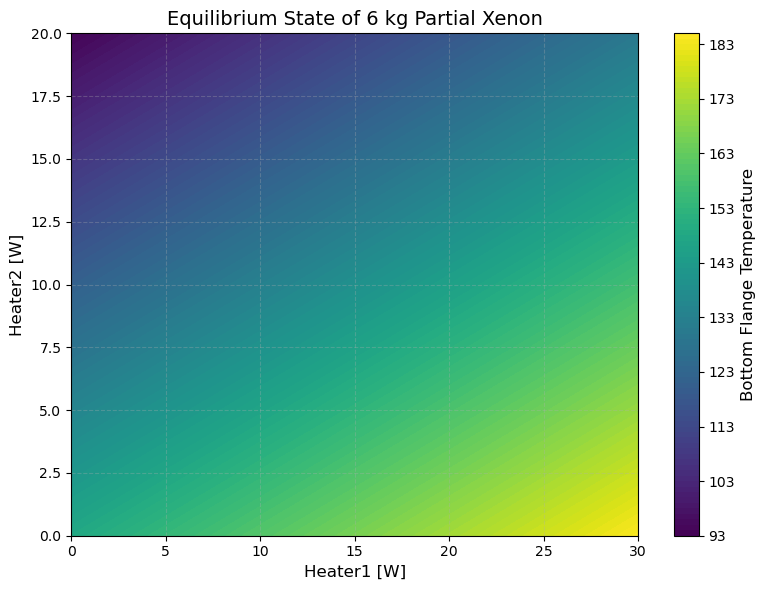

In [234]:
fig, ax = plt.subplots(figsize=(8, 6), dpi=100)

# cmap：'viridis', 'plasma', 'coolwarm', 'jet', 'rainbow', so on
cp = ax.contourf(H2, H1, Tb_calc, levels=100, cmap='viridis')

colorbar = fig.colorbar(cp)
colorbar.set_label('Bottom Flange Temperature', fontsize=12)

ax.set_title(title_string, fontsize=14)
ax.set_ylabel('Heater2 [W]', fontsize=12)
ax.set_xlabel('Heater1 [W]', fontsize=12)

ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

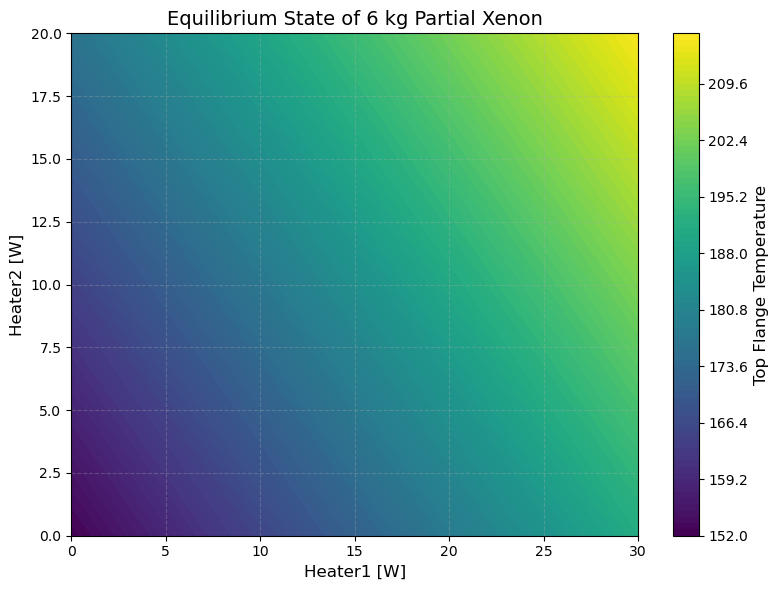

In [235]:
fig, ax = plt.subplots(figsize=(8, 6), dpi=100)

# cmap：'viridis', 'plasma', 'coolwarm', 'jet', 'rainbow', so on
cp = ax.contourf(H2, H1, Tt_calc, levels=100, cmap='viridis')

colorbar = fig.colorbar(cp)
colorbar.set_label('Top Flange Temperature', fontsize=12)

ax.set_title(title_string, fontsize=14)
ax.set_ylabel('Heater2 [W]', fontsize=12)
ax.set_xlabel('Heater1 [W]', fontsize=12)

ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()